In [1]:
from matplotlib import pyplot as plt
from scipy.interpolate import CubicSpline
import numpy as np
from UTILS import InitialCondition
from scipy.stats import maxwell

# Costants

In [2]:
Temperature = 5e-3 # K
Temperature_transv = 10e-3 # K

class constants:
    def __init__(self, Temperature, Temperature_transv):
        self.Temperature = Temperature
        self.Temperature_transv = Temperature_transv
    mass = 1.6735575e-27 # kg, mass Hbar
    bohr_magneton = 9.2740100657e-24 # J/T, CODATA 2022
    kB = 1.380649e-23   # J/K
    #Temperature = 5e-3 # K
    #Temperature_transv = 2*10e-3 # K
    harmonic_degree = 2 # degree of the harmonic potential
    harmonic_coefficient = .5 # coefficient harmonic potential
    Zmin = -0.605 # m
    Zmax = -0.481 # m
    Zmid = -0.544 # m
    zacceptance_min = -0.775
    zacceptance_max = -0.325
    mu_eff_over_m = bohr_magneton / mass

CONSTANTS = constants(Temperature, Temperature_transv)
print(CONSTANTS.Temperature, CONSTANTS.Temperature_transv)

0.005 0.01


# Functions to make the plot nicer

In [3]:
# Make Plot Nicer
def plotter_nicer(titlex, titley):
    plt.ylabel(titley, fontsize = 18, loc = "top")
    plt.xlabel(titlex, loc = 'right', fontsize = 18)
    
    plt.grid()
    plt.minorticks_on()
    plt.grid(which='major', linestyle='-', color='black', alpha = 0.5) #Griglia maggiore: linea continua nera
    plt.grid(which='minor', linestyle=':', color='gray') #Griglia minore: linea tratteggiata grigia

def labelfactory(x, y , listlist, labels):
    plt.xticks(labels,[f"{item:.2f}g" for item in labels], rotation = 30)      # etichette

    texts = []
    for xi, yi, label in zip(x, y, listlist):
        texts.append(plt.text(xi - 0.2, yi, label, rotation = 30))
    
    adjust_text(texts, x, y, arrowprops=dict(arrowstyle="->", color='white'))
    
    plt.legend(fontsize = 12)

# Boltzmann-Maxwell distribution

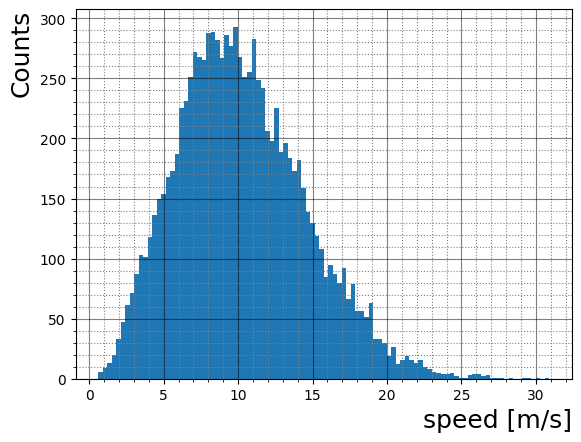

In [4]:
scale = np.sqrt(CONSTANTS.kB * CONSTANTS.Temperature/CONSTANTS.mass)
sampling = maxwell.rvs(scale = scale, size = 10000)
plt.hist(sampling, bins = 100)
plotter_nicer("speed [m/s]", "Counts")

In [5]:
data = np.genfromtxt("Bfield/PreGravity_20mT_well_0g.csv", 
                       delimiter = ",", 
                       names = True, 
                       filling_values=np.nan, 
                       #unpack =  True
                      )
Z = data['\ufeffz_mm__Bz_on_axis']/1000

print(type(data))
print(10*"-")
print(data)
print(10*"-")
print(data[0])
print(10*"-")
print(data[0][0], data[0][1] )
print(10*"-")
print(data["z_mm__Min_B_on_wall"])
#Z, Potential, Z_minwall, PotentialMinWall 

<class 'numpy.ndarray'>
----------
[(-3000., -0.00466533, -1000. , 0.779155)
 (-2997., -0.00465643,  -999.5, 0.780256)
 (-2994., -0.0046475 ,  -999. , 0.781354) ...
 ( 2994.,  0.00595184,     nan,      nan)
 ( 2997.,  0.00595344,     nan,      nan)
 ( 3000.,  0.00595506,     nan,      nan)]
----------
(-3000., -0.00466533, -1000., 0.779155)
----------
-3000.0 -0.00466533
----------
[-1000.   -999.5  -999.  ...     nan     nan     nan]


## Plot of the Magnetic field profile, 17mT well

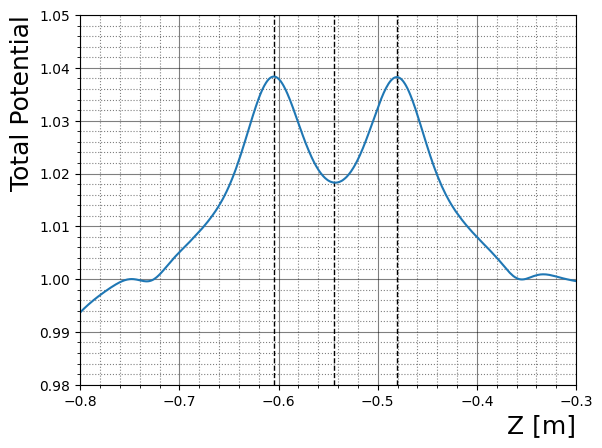

In [6]:
plotter_nicer("Z [m]", "Total Potential")
plt.xlim(-0.800, -0.300)
plt.ylim(0.98, 1.05)
plt.axvline(-0.605, linestyle = "--", color = "black", linewidth = 1)
plt.axvline(-0.544, linestyle = "--", color = "black", linewidth = 1)
plt.axvline(-0.481, linestyle = "--", color = "black", linewidth = 1)
plt.plot(data['\ufeffz_mm__Bz_on_axis']/1000,data["Total_potential_T__Bz_on_axis"] )

## Spline Creation

- **Bfield(x)** Magnetic Field Potential

In [7]:
Z = data['\ufeffz_mm__Bz_on_axis']/1000
print(Z)
Uz = data["Total_potential_T__Bz_on_axis"]
Bfield = CubicSpline(Z, Uz)

[-3.    -2.997 -2.994 ...  2.994  2.997  3.   ]


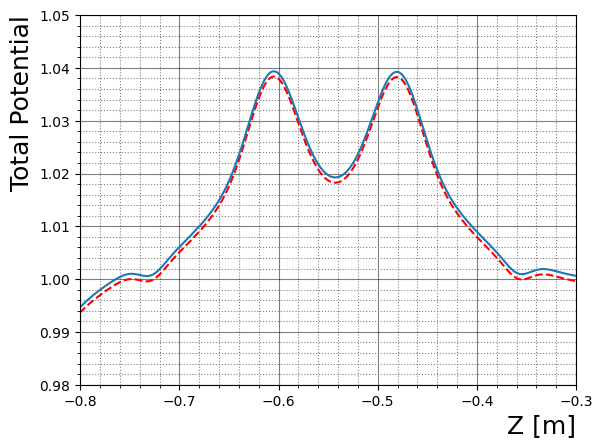

In [8]:
plotter_nicer("Z [m]", "Total Potential")
plt.xlim(-0.800, -0.300)
plt.ylim(0.98, 1.05)

plt.plot(Z, Bfield(Z), linestyle = "--", color = "red")
plt.plot(Z,data["Total_potential_T__Bz_on_axis"] + 0.001 )

# Energy Distribution

In [9]:
from scipy.optimize import brentq

<ErrorbarContainer object of 3 artists>

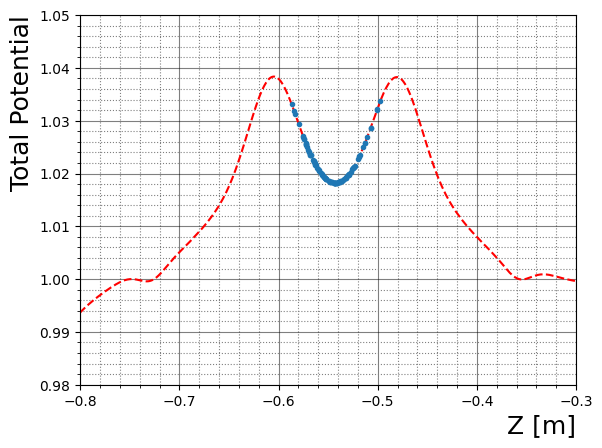

In [10]:
nAtoms = 100

Zinit = [InitialCondition(Bfield, CONSTANTS)[1] for i in range(0,nAtoms)]

plotter_nicer("Z [m]", "Total Potential")
plt.xlim(-0.800, -0.300)
plt.ylim(0.98, 1.05)
plt.plot(Z, Bfield(Z), linestyle = "--", color = "red")
plt.errorbar(Zinit, Bfield(Zinit), linestyle = "", marker = ".")

[ 6.33791151 -3.04553557 -4.4289743  ...  7.85250112  9.14899966
  4.70339253]


(array([226., 432., 608., 716., 699., 677., 637., 534., 350., 112., 132.,
        296., 508., 636., 706., 780., 663., 600., 460., 228.]),
 array([-1.05183360e+01, -9.46667919e+00, -8.41502240e+00, -7.36336561e+00,
        -6.31170882e+00, -5.26005203e+00, -4.20839524e+00, -3.15673845e+00,
        -2.10508166e+00, -1.05342487e+00, -1.76808348e-03,  1.04988871e+00,
         2.10154550e+00,  3.15320229e+00,  4.20485908e+00,  5.25651587e+00,
         6.30817266e+00,  7.35982945e+00,  8.41148624e+00,  9.46314303e+00,
         1.05147998e+01]),
 <BarContainer object of 20 artists>)

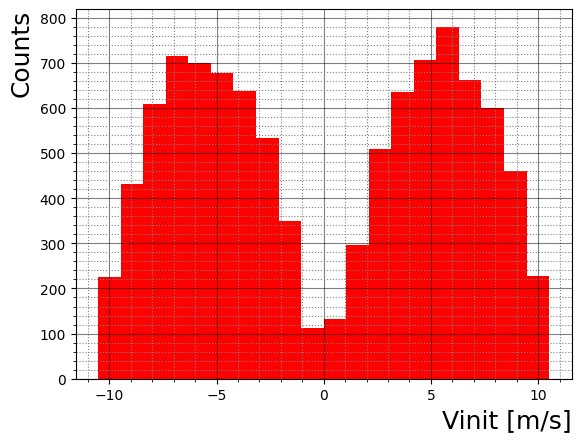

In [11]:
nAtoms = 10000

Vinit = np.array([InitialCondition(Bfield, CONSTANTS)[0] for i in range(0,nAtoms)]).flatten()
print(Vinit)
plotter_nicer("Vinit [m/s]", "Counts")
plt.hist(Vinit, bins = 20, linestyle = "--", color = "red")

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from matplotlib import rc
rc('animation', html='jshtml')

# fig, ax = plt.subplots()
# x = np.linspace(0, 2*np.pi, 200)
# pt, = ax.plot([], [], 'o')
# ax.set_xlim(0, 2*np.pi)
# ax.set_ylim(-1.2, 1.2)

# def init():
#     pt.set_data([], [])
#     return (pt,)

# def update(i):
#     t = i/30
#     pt.set_data([t%(2*np.pi)], [np.sin(t)])
#     return (pt,)

# ani = FuncAnimation(fig, update, init_func=init, frames=300, interval=20, blit=True)
# plt.close(fig)
# HTML(ani.to_jshtml())

# Testing 3d code

In [13]:
from UTILS import Gradient_Computation_1d, dB_seg

In [14]:
data = np.genfromtxt("Bfield/PreGravity_20mT_well_0g.csv", 
                       delimiter = ",", 
                       names = True, 
                       filling_values=np.nan, 
                       #unpack =  True
                      )
Z = data['\ufeffz_mm__Bz_on_axis']/1000
Uz = data["Total_potential_T__Bz_on_axis"]
print(Z, Uz)
Bfield_20mT_pregravity = CubicSpline(Z, Uz)

data = np.genfromtxt("Bfield/GravityRelease_17mT_well_0g.csv", 
                       delimiter = ",", 
                       names = True, 
                       filling_values=np.nan, 
                       #unpack =  True
                      )
Z = data['\ufeffz_mm__Bz_on_axis']/1000
Uz = data["Total_potential_T__Bz_on_axis"]
print(Z, Uz)
Bfield_17mT = CubicSpline(Z, Uz)

data = np.genfromtxt("Bfield/GravityRelease_5mT_well_0g.csv", 
                       delimiter = ",", 
                       names = True, 
                       filling_values=np.nan, 
                       #unpack =  True
                      )
Z = data['\ufeffz_mm__Bz_on_axis']/1000
Uz = data["Total_potential_T__Bz_on_axis"]
print(Z, Uz)
Bfield_5mT = CubicSpline(Z, Uz)

data = np.genfromtxt("Bfield/GravityRelease_2p5mT_well_0g.csv", 
                       delimiter = ",", 
                       names = True, 
                       filling_values=np.nan, 
                       #unpack =  True
                      )
Z = data['\ufeffz_mm__Bz_on_axis']/1000
Uz = data["Total_potential_T__Bz_on_axis"]
print(Z, Uz)
Bfield_2p5mT = CubicSpline(Z, Uz)

[-3.    -2.997 -2.994 ...  2.994  2.997  3.   ] [-0.00466533 -0.00465643 -0.0046475  ...  0.00595184  0.00595344
  0.00595506]
[-3.    -2.997 -2.994 ...  2.994  2.997  3.   ] [-0.00466541 -0.0046565  -0.00464758 ...  0.00595181  0.00595341
  0.00595504]
[-3.    -2.997 -2.994 ...  2.994  2.997  3.   ] [-0.00466567 -0.00465677 -0.00464784 ...  0.00595172  0.00595332
  0.00595495]
[-3.    -2.997 -2.994 ...  2.994  2.997  3.   ] [-0.00466573 -0.00465683 -0.0046479  ...  0.00595171  0.00595331
  0.00595493]


## Create Magnetic field and Gradient Grid

In [15]:
zgrid = np.linspace(-0.800, -0.300, 100000)   # half mm of discretization 
z0 = zgrid[0]
dz = np.diff(zgrid)[0]

dBfield_20mT_pregravity_dz  = np.array(Gradient_Computation_1d(Bfield_20mT_pregravity, zgrid))
Bfield_20mT_pregravity_grid = np.array(Bfield_20mT_pregravity(zgrid))

dBfield_17mT_dz             = np.array(Gradient_Computation_1d(Bfield_17mT, zgrid))
Bfield_17mT_grid            = np.array(Bfield_17mT(zgrid))

dBfield_5mT_dz              = np.array(Gradient_Computation_1d(Bfield_5mT, zgrid))
Bfield_5mT_grid             = np.array(Bfield_5mT(zgrid))

dBfield_2p5mT_dz            = np.array(Gradient_Computation_1d(Bfield_2p5mT, zgrid))
Bfield_2p5mT_grid           = np.array(Bfield_2p5mT(zgrid))

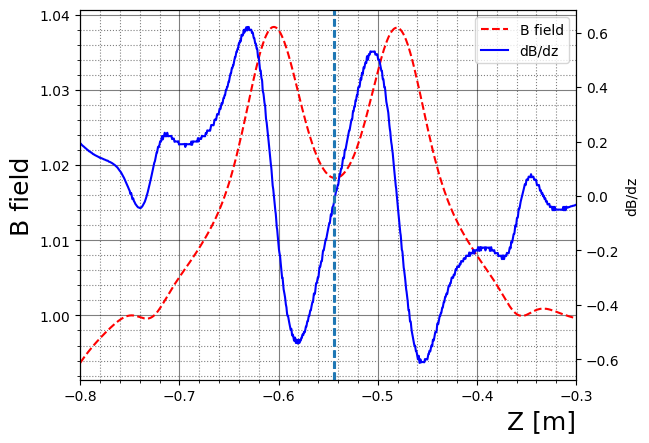

In [16]:
fig, ax1 = plt.subplots()

plotter_nicer("Z [m]", "Total Potential")
ax1.set_xlim(-0.800, -0.300)

# Primo asse y (ad esempio per il potenziale)
ax1.plot(zgrid, Bfield_20mT_pregravity_grid, linestyle="--", color="red", label="B field")

# Secondo asse y per la derivata
ax2 = ax1.twinx()
ax2.plot(zgrid, dBfield_20mT_pregravity_dz, color="blue", label="dB/dz")
#ax2.axvline(CONSTANTS.Zmid)

ax2.axvline(CONSTANTS.Zmid, linestyle = "--")
ax2.axvline(CONSTANTS.Zmid + 0.0005, linestyle = "--")

# Etichette
ax1.set_ylabel("B field")
ax2.set_ylabel("dB/dz")

# Se vuoi una legenda combinata:
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="best")

plt.show()

In [17]:
# test gradient computation

a = dB_seg(CONSTANTS.Zmid,0,0,
       0,10,
       z0, dz,
       dBfield_20mT_pregravity_dz,
       Bfield_20mT_pregravity_grid,
       dBfield_17mT_dz,
       Bfield_17mT_grid)
print(f"[{a[0]},{a[1]},{a[2]}]")

a = dB_seg(-0.51,0,0,
       0,10,
       z0, dz,
       dBfield_20mT_pregravity_dz,
       Bfield_20mT_pregravity_grid,
       dBfield_17mT_dz,
       Bfield_17mT_grid)
print(f"[{a[0]},{a[1]},{a[2]}]")

[0.0,0.0,-0.020046594784606242]
[0.0,0.0,0.5000035095563682]


## Test 3d Initial Conditions

In [18]:
from UTILS import InitialCondition_3d

In [19]:
# Initialize the particles
Z_array = []
X_array = []
Y_array = []
V_array = []
Time_Annihilation = []
Annihilation      = []
for _ in range(nAtoms):
    #print("Extracting values:")
    Vinit, Rinit = InitialCondition_3d(Bfield_20mT_pregravity, CONSTANTS) # Define initial conditions of the simulation
    # Initial position
    Z_array.append(Rinit[0])
    X_array.append(Rinit[1])
    Y_array.append(Rinit[2])
    
    V_array.append(Vinit)             # Initial speed
    Time_Annihilation.append(np.nan)  # Time annihilation
    Annihilation.append(False)        # Annihilation bool array

Z_array = np.array(Z_array).flatten()
V_array = np.array(V_array)
print(V_array.shape)

Time_Annihilation = np.array(Time_Annihilation).flatten()
Annihilation = np.array(Annihilation).flatten()

(10000, 3)


Text(0.5, 0, 'velocity [m/s]')

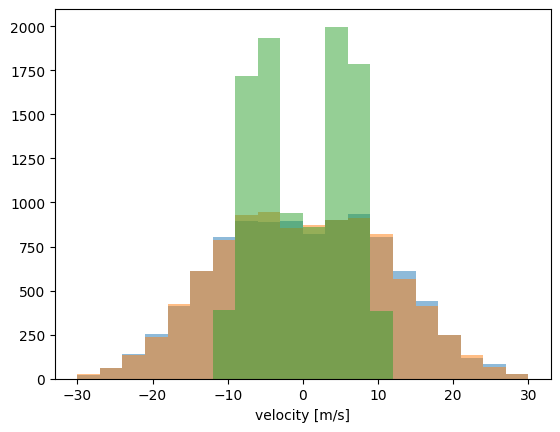

In [20]:
plt.hist(V_array[:,0], range = (-30, 30), bins = 20, alpha = .5)
plt.hist(V_array[:,1], range = (-30, 30), bins = 20, alpha = .5)
plt.hist(V_array[:,2], range = (-30, 30), bins = 20, alpha = .5)
plt.xlabel("velocity [m/s]")

# Test simulation code, simulate 1 particle and follow the trajectory

In [21]:
from UTILS import step_all_particles, InitialCondition, dt, harmonic_degree, harmonic_coefficient
import time

In [22]:
# Initialize the atom
Time = 0
R_array = []
V_array = []
Time_Annihilation = []
Annihilation      = []

Vinit, Rinit = InitialCondition_3d(Bfield_20mT_pregravity, CONSTANTS) # Define initial conditions of the simulation
Vinit[1] = 0

# Initial position
R_array.append(Rinit)

V_array.append(Vinit)             # Initial speed
Time_Annihilation.append(np.nan)  # Time annihilation
Annihilation.append(False)

dB_buffer = np.empty(3, dtype=np.float64)
R_array = np.array(R_array)
V_array = np.array(V_array)
Time_Annihilation = np.array(Time_Annihilation).flatten()
Annihilation = np.array(Annihilation).flatten()

In [23]:
start_time = time.time()

Xv = []
Yv = []
Zv = []

Vxv = []
Vyv = []
Vzv = []

for frame in range(0,int(10/dt)):
    if(frame % 1000 == 0):
        end = time.time() - start_time
        print(f"frame {frame}, time {end:.2f}s, R {R_array[0,2]}, V {V_array[0,2]}")

    seg_id   = 1   # plateau
    Tloc     = 0.0
    ramp_len = 0.0
    dBinit   = dBfield_20mT_pregravity_dz  # non usato
    Binit    = Bfield_20mT_pregravity_grid 
    dBfinal  = dBfield_17mT_dz             # usi questo
    Bfinal   = Bfield_17mT_grid

    # step di tutte le particelle (in-place)
    step_all_particles(
        R_array, V_array, Time,
        seg_id, Tloc, ramp_len,
        z0, dz,
        dBinit, 
        Binit,
        dBfinal,
        Bfinal,
        Annihilation, Time_Annihilation,
        dB_buffer
    )

    # Get trajectory
    Xv.append(R_array[0,0])
    Yv.append(R_array[0,1])
    Zv.append(R_array[0,2])

    Vxv.append(V_array[0,0])
    Vyv.append(V_array[0,1])
    Vzv.append(V_array[0,2])
    
    # Avanza il tempo UNA volta per frame
    Time += dt

frame 0, time 0.00s, R -0.5359820953652756, V -5.665266800723133
frame 1000, time 4.03s, R -0.562450198683689, V -2.3861075779265
frame 2000, time 4.04s, R -0.5524466697774606, V 5.388790604407577
frame 3000, time 4.04s, R -0.5243522037082138, V 3.0128258752054746
frame 4000, time 4.04s, R -0.5309914816092193, V -4.991966655484054
frame 5000, time 4.04s, R -0.5596345559477857, V -3.7227555298858874
frame 6000, time 4.05s, R -0.5574823459324959, V 4.385477509115842
frame 7000, time 4.05s, R -0.5283202396576993, V 4.40792486150752
frame 8000, time 4.05s, R -0.5264637484014927, V -3.8581284809242375
frame 9000, time 4.05s, R -0.5554888919939823, V -4.854654249749491
frame 10000, time 4.06s, R -0.5610291362953124, V 3.1660291181448974
frame 11000, time 4.06s, R -0.5331452379729202, V 5.338942967432935
frame 12000, time 4.06s, R -0.5231338452996303, V -2.329715030119237
frame 13000, time 4.07s, R -0.5499273493472521, V -5.691996340244488
frame 14000, time 4.07s, R -0.5632884662909267, V 1.6

In [24]:
print(Xv[:10])

[0.0009827709601453953, 0.0019655280872801864, 0.0029482575492305314, 0.003930945515068719, 0.004913578155192305, 0.00589614164115386, 0.006878622145786691, 0.007861005843430535, 0.00884327891032858, 0.009825427524733941]


In [25]:
!pip install ipympl

Defaulting to user installation because normal site-packages is not writeable


In [26]:
def grid_plotter(zc, height):
    xx = np.ones(100)*zc
    zz = np.ones(100)*(height)
    yy = np.linspace(-0.250, 0.250, 100)
    ax.plot(xx, yy, zz, linestyle = "--", color = "black", alpha = 0.75)
    ax.plot(xx, zz, yy, linestyle = "--", color = "black", alpha = .75)

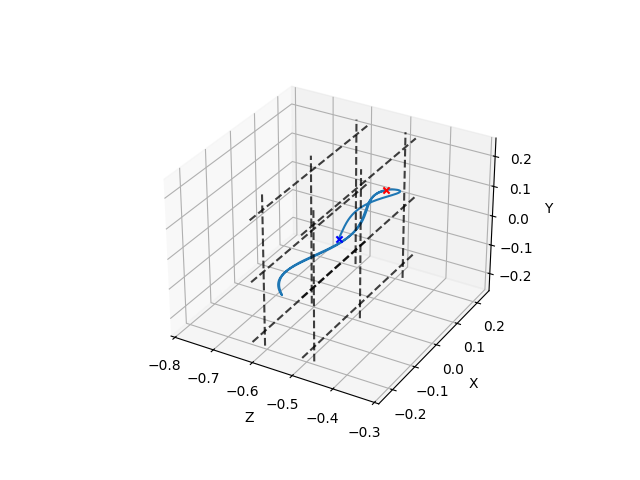

In [27]:
%matplotlib widget

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

start = 0
end = 2000

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# plot starting point
ax.scatter(Zv[start], Xv[start], Yv[start], color = "blue", marker = "x")
# plot ending point
ax.scatter(Zv[end], Xv[end], Yv[end], color = "red", marker = "x")
# plot the trajectory
ax.plot(Zv[:end], Xv[:end], Yv[:end])

height = np.linspace(-0.2, 0.2, 3)

for h in height:
    grid_plotter(CONSTANTS.Zmin, h)
    grid_plotter(CONSTANTS.Zmax, h)


ax.set_xlim(-0.800, -0.300)
ax.set_ylim(-0.250, +0.250)
ax.set_zlim(-0.250, +0.250)

ax.set_xlabel("Z")
ax.set_ylabel("X")
ax.set_zlabel("Y")

plt.show()

# Visualization of the motion inside the Potential Well

In [28]:
def BfieldExtended(function, X, Y, Z, k, p):
    "3d extent of the magnetic field model, assuming harmonic potential"
    r = np.sqrt(X*X + Y*Y)
    return function(Z) * (1 + k*r**p)

def slice_plotter(f, Bfield, zc, height, alpha, ax):
    zcomp = np.linspace(-0.8, -0.3, 100)
    ycomp = np.ones(100)*(0)
    xcomp = np.ones(100)*(height)
    
    Potential = f(Bfield, 
               xcomp, 
               ycomp, # y component
               zcomp, # z component
               harmonic_coefficient, harmonic_degree)
    ax.plot(zcomp, xcomp , Potential, linestyle = "-", color = "black", alpha = alpha)

Text(0.5, 0, 'Potential')

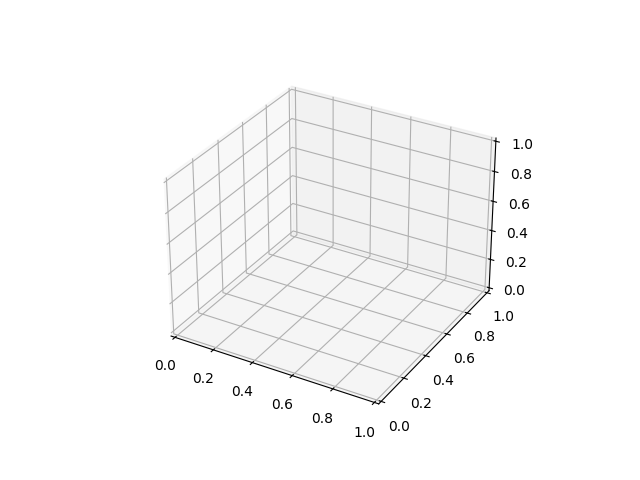

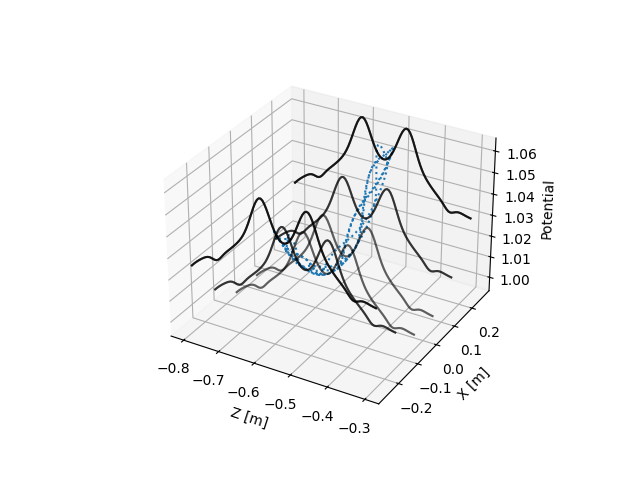

In [29]:
fig = plt.figure(2)
ax = fig.add_subplot(111, projection='3d')

start = 0
end = 5000

fig = plt.figure()
ax1 = fig.add_subplot(111, projection='3d')

# Trajectoy in Potential
Potential = BfieldExtended(Bfield_17mT, 
                           np.array(Xv), 
                           np.array(Yv),
                           np.array(Zv),
                           harmonic_coefficient, harmonic_degree)
# Plot trajectory in the potential well
ax1.plot(Zv[:end], Xv[:end], Potential[:end], linestyle = "dotted")

#slice


height = np.linspace(-0.25, 0.25, 6)

for h in height:
    alpha = 2 * np.abs(h)/(height[-1] -  height[0]) * 0.4 + 0.3
    slice_plotter(BfieldExtended, Bfield_17mT, 0, h, alpha, ax1)
    slice_plotter(BfieldExtended, Bfield_17mT, 0, h, alpha, ax1)



# ax.set_xlim(-0.800, -0.300)
# ax.set_ylim(-0.250, +0.250)
# ax.set_zlim(-0.250, +0.250)

ax1.set_xlabel("Z [m]")
ax1.set_ylabel("X [m]")
ax1.set_zlabel("Potential")

#plt.show()

## Visualize potential

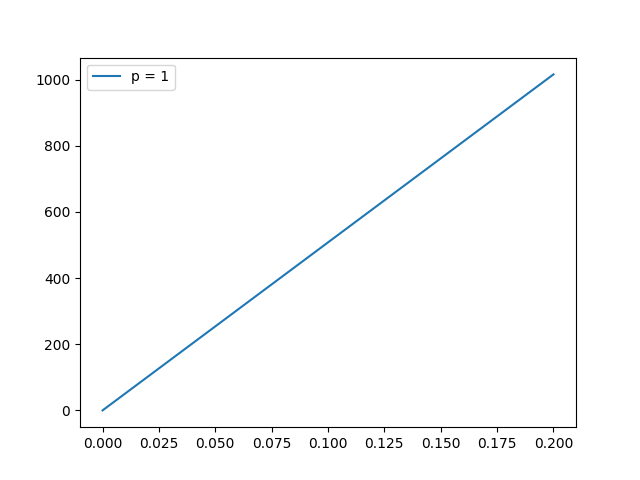

In [30]:
plt.figure(4)

x = np.linspace(0, 0.20, 100)
degree = 1
Potential = BfieldExtended(Bfield_17mT, 
                           x, 
                           np.ones(100)*0,
                           np.ones(100)*CONSTANTS.Zmid,
                           0.5, 
                           degree) * 10000
Potential -= min(Potential)

plt.plot(x, Potential, label = f"p = {degree}")
plt.legend()
plt.show()